In [ ]:
import time
import requests
import pandas as pd
import os

from selenium import webdriver
from selenium.webdriver import ActionChains
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.keys import Keys
from bs4 import BeautifulSoup

# pip install openpyxl # 이걸 해야 시트로 해서저장이 됨

<html lang="ko"><head>


	
	
		
			
			
				<title>해외증시 : Npay 증권</title>
			
		
	




<meta http-equiv="Content-Type" content="text/html; charset=utf-8">

<meta http-equiv="Content-Script-Type" content="text/javascript">
<meta http-equiv="Content-Style-Type" content="text/css">
<meta name="apple-mobile-web-app-title" content="Npay 증권">





	
    
        <meta property="og:url" content="https://finance.naver.com/world/">
        
			
		    
		    	<meta property="og:title" content="해외증시 : Npay 증권">
		     
		
		
			
			   <meta property="og:description" content="관심종목의 실시간 주가를 가장 빠르게 확인하는 곳">
		    
		    
		
		 
			
			    <meta property="og:image" content="https://ssl.pstatic.net/static/m/stock/im/2016/08/og_stock-200.png">
		    
		    
		
    

<meta property="og:type" content="article">
<meta property="og:article:thumbnailUrl" content="">
<meta property="og:article:author" content="Npay 증권">
<meta property="og:article:author:url" content="http://FINANCE.NAVER.COM">






<link re
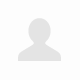
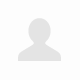

AttributeError: 'NoneType' object has no attribute 'text'

In [18]:
url = "https://finance.naver.com/"

driver = webdriver.Chrome()
driver.maximize_window()

driver.get(url)

time.sleep(2)

# action = ActionChains(driver)

domestic = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((
            By.CSS_SELECTOR,
            "#menu > ul > li.m2 > a > span"
        ))
    )


domestic.click()  # popularItemList


# top10_finential = driver.find_elements(
#         By.ID,
#         "popularItemList"
#     )

req = driver.page_source

soup = BeautifulSoup(req, "html.parser")

top10_finential = soup.find("ul", "lst_pop").find_all("li")

fi_top_list = []
fi_name_list = []
fi_price_list = []

for row in top10_finential:
    fi_top = row.find("em").text
    fi_name = row.find("a").text
    fi_price = row.find("span").text

    fi_top_list.append(fi_top)
    fi_name_list.append(fi_name)
    fi_price_list.append(fi_price)

    #print(f"{fi_name}, {fi_price}")

df01 = pd.DataFrame({
    "순위": fi_top_list,
    '이름': fi_name_list,
    '가격': fi_price_list
})


international = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((
        By.CSS_SELECTOR, "#menu > ul > li.m3 > a > span"
    ))
)


international.click()

req = driver.page_source
soup = BeautifulSoup(req, "html.parser")



# 일단 스크롤 넣어보고
scroll_area = driver.find_element(By.XPATH,"/html/body")
before = 0

while True:
    driver.execute_script(
        "arguments[0].scrollTop = arguments[0].scrollHeight",
        scroll_area
    )

    time.sleep(1)

    after = driver.execute_script(
        "return arguments[0].scrollHeight",
        scroll_area
    )
    if before == after:
        break

    before = after


time.sleep(3)

important_international = driver.find_elements(
    By.XPATH,
    '//*[@id="americaIndex"]/thead/tr[position()>1]'
)

important_international =  soup.find('thead').find_all('tr')# driver.find_elements(By.CSS_SELECTOR, "#americaIndex tbody tr") # soup.find("tbody").find_all("tr")[1:]

print(driver.page_source)
print(soup.select("thead"))

international_nation_list = []
international_name_list = []
international_cur_price_list = []
international_percent_list = []
international_time_list = []

for row in important_international:
    international_nation = row.select_one("td.tb_td a").text
    international_name = row.select_one("td.tb_td2 span").text
    international_cur_price = row.select_one("td.tb_td3 span").text
    international_percent = row.select_one("td.tb_td5 span").text
    international_time = row.select_one("td.tb_td7 span").text

    international_nation_list.append(international_nation)
    international_name_list.append(international_name)
    international_cur_price_list.append(international_cur_price)
    international_percent_list.append(international_percent)
    international_time_list.append(international_time)

driver.quit()

# df.to_excel("fiential_top10.xlsx", index=False) # 기본 구조

df02 = pd.DataFrame({
    "국가": international_nation_list,
    '지수명': international_name_list,
    '현재가': international_cur_price_list,
    "등락률": international_percent_list,
    "시간": international_time_list

})

with pd.ExcelWriter("finential.xlsx") as writer:
    df01.to_excel(writer, sheet_name="국내증시 탑10", index=False)
    df01.to_excel(writer, sheet_name="해외 주요 증시", index=False)